## Import the libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the datasets for combined analysis

In [ ]:
# Load cleaned Google Play Store App data
app_data = pd.read_csv('D:\PlayStore App Review Analysis(EDA Project)\data\processed\Cleaned_Data_App.csv')

In [6]:
# Load cleaned Google Play Store User Reviews data
review_data = pd.read_csv('D:\PlayStore App Review Analysis(EDA Project)\data\processed\Cleaned_User_Reviews.csv')

# Basic Inspection

In [7]:
# checking the shape of the datasets
print("App Data Shape:", app_data.shape)
print("Review Data Shape:", review_data.shape)

App Data Shape: (9658, 13)
Review Data Shape: (29697, 5)


In [ ]:
# check the info for the dataset for the app
print("\nApp Data Info:")
app_data.info()


App Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 9658 entries, 0 to 9657
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9658 non-null   str    
 1   Category        9658 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9658 non-null   int64  
 4   Size            8431 non-null   float64
 5   Installs        9658 non-null   int64  
 6   Type            9658 non-null   str    
 7   Price           9658 non-null   float64
 8   Content Rating  9658 non-null   str    
 9   Genres          9658 non-null   str    
 10  Last Updated    9658 non-null   str    
 11  Current Ver     9650 non-null   str    
 12  Android Ver     9656 non-null   str    
dtypes: float64(3), int64(2), str(8)
memory usage: 981.0 KB


In [10]:
# check the info for the dataset for the reviews
print("\nReview Data Info:")
review_data.info()


Review Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 29697 entries, 0 to 29696
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29697 non-null  str    
 1   Translated_Review       29692 non-null  str    
 2   Sentiment               29697 non-null  str    
 3   Sentiment_Polarity      29697 non-null  float64
 4   Sentiment_Subjectivity  29697 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.1 MB


# Aggregate User Reviews By App

In [ ]:
# count the number of reviews for each app and their sentiment
review_summary = review_data.groupby('App')['Sentiment'].value_counts().unstack(fill_value=0)

In [13]:
review_summary

Sentiment,Negative,Neutral,Positive
App,,,
10 Best Foods for You,5,11,79
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,27
11st,7,10,23
1800 Contacts - Lens Store,3,5,32
1LINE – One Line with One Touch,8,3,27
...,...,...,...
Hotels.com: Book Hotel Rooms & Find Vacation Deals,12,5,22
Hotspot Shield Free VPN Proxy & Wi-Fi Security,3,14,15
Hotstar,14,4,14


In [14]:
# get the total number of reviews for each app
review_summary['Total_Reviews'] = review_summary.sum(axis=1)

In [15]:
review_summary

Sentiment,Negative,Neutral,Positive,Total_Reviews
App,,,,
10 Best Foods for You,5,11,79,95
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,27,36
11st,7,10,23,40
1800 Contacts - Lens Store,3,5,32,40
1LINE – One Line with One Touch,8,3,27,38
...,...,...,...,...
Hotels.com: Book Hotel Rooms & Find Vacation Deals,12,5,22,39
Hotspot Shield Free VPN Proxy & Wi-Fi Security,3,14,15,32
Hotstar,14,4,14,32


In [19]:
# calculating the percentage of postive, negative and netural reviews for each app
review_summary['Positive_Percentage'] = (review_summary['Positive'] / review_summary['Total_Reviews'] * 100).round(2)
review_summary['Negative_Percentage'] = (review_summary['Negative'] / review_summary['Total_Reviews'] * 100).round(2)
review_summary['Neutral_Percentage'] = (review_summary['Neutral'] / review_summary['Total_Reviews'] * 100).round(2)

In [20]:
review_summary

Sentiment,Negative,Neutral,Positive,Total_Reviews,Positive_Percentage,Negative_Percentage,Neutral_Percentage
App,,,,,,,
10 Best Foods for You,5,11,79,95,83.16,5.26,11.58
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,27,36,75.00,2.78,22.22
11st,7,10,23,40,57.50,17.50,25.00
1800 Contacts - Lens Store,3,5,32,40,80.00,7.50,12.50
1LINE – One Line with One Touch,8,3,27,38,71.05,21.05,7.89
...,...,...,...,...,...,...,...
Hotels.com: Book Hotel Rooms & Find Vacation Deals,12,5,22,39,56.41,30.77,12.82
Hotspot Shield Free VPN Proxy & Wi-Fi Security,3,14,15,32,46.88,9.38,43.75
Hotstar,14,4,14,32,43.75,43.75,12.50


In [24]:
#  calculte the average of the polarity and the subjectivity for each app
sentiment_avg = review_data.groupby('App')[
    ['Sentiment_Polarity', 'Sentiment_Subjectivity']
].mean().round(2)


In [25]:
sentiment_avg.head()

,Sentiment_Polarity,Sentiment_Subjectivity
App,,
10 Best Foods for You,0.47,0.49
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,0.36,0.51
11st,0.18,0.44
1800 Contacts - Lens Store,0.32,0.59
1LINE – One Line with One Touch,0.20,0.56


In [ ]:
# adding the avg sentiment data to the review_summary dataframe
review_summary = review_summary.join(sentiment_avg)

In [27]:
review_summary.head()

,Negative,Neutral,Positive,Total_Reviews,Positive_Percentage,Negative_Percentage,Neutral_Percentage,Sentiment_Polarity,Sentiment_Subjectivity
App,,,,,,,,,
10 Best Foods for You,5,11,79,95,83.16,5.26,11.58,0.47,0.49
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,27,36,75.00,2.78,22.22,0.36,0.51
11st,7,10,23,40,57.50,17.50,25.00,0.18,0.44
1800 Contacts - Lens Store,3,5,32,40,80.00,7.50,12.50,0.32,0.59
1LINE – One Line with One Touch,8,3,27,38,71.05,21.05,7.89,0.20,0.56


### Review Aggregation — Observation

- Since the User Review dataset contains multiple reviews for the same application, the review-level data was aggregated by `App` to create an **app-level review summary**.
- The number of **Positive, Negative, and Neutral reviews** was calculated for each app to understand the composition of user sentiment.
- The total number of reviews was calculated by summing the three sentiment categories for each app.
- Sentiment percentages were calculated to provide a **normalized view of user sentiment**, making comparisons between apps with different numbers of reviews more meaningful.
- The average `Sentiment_Polarity` and `Sentiment_Subjectivity` were calculated to summarize the **overall sentiment strength and subjectivity** of reviews for each app.
- The resulting summary contains **one row per app with available review data**, providing the required app-level sentiment metrics for the combined analysis.

In [29]:
# resetting the index of review_summary to make the app a normal column
review_summary = review_summary.reset_index()

In [30]:
review_summary.head()

,App,Negative,Neutral,Positive,Total_Reviews,Positive_Percentage,Negative_Percentage,Neutral_Percentage,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,5,11,79,95,83.16,5.26,11.58,0.47,0.49
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,27,36,75.00,2.78,22.22,0.36,0.51
2,11st,7,10,23,40,57.50,17.50,25.00,0.18,0.44
3,1800 Contacts - Lens Store,3,5,32,40,80.00,7.50,12.50,0.32,0.59
4,1LINE – One Line with One Touch,8,3,27,38,71.05,21.05,7.89,0.20,0.56


## Merging the Review_Summary With the App Dataset

In [31]:
# merging the app_data and review_summary dataframes on the 'App' column
combined_data = pd.merge(
    app_data,
    review_summary,
    on='App',
    how='left'
)

In [ ]:
# cheking the shape of the combined dataset after merging the app_data and  review_summary dataframe
combined_data.shape

(9658, 22)

In [34]:
# checking the combined data info
combined_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9658 entries, 0 to 9657
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     9658 non-null   str    
 1   Category                9658 non-null   str    
 2   Rating                  8196 non-null   float64
 3   Reviews                 9658 non-null   int64  
 4   Size                    8431 non-null   float64
 5   Installs                9658 non-null   int64  
 6   Type                    9658 non-null   str    
 7   Price                   9658 non-null   float64
 8   Content Rating          9658 non-null   str    
 9   Genres                  9658 non-null   str    
 10  Last Updated            9658 non-null   str    
 11  Current Ver             9650 non-null   str    
 12  Android Ver             9656 non-null   str    
 13  Negative                816 non-null    float64
 14  Neutral                 816 non-null    float64
 15

In [36]:
combined_data.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Android Ver,Negative,Neutral,Positive,Total_Reviews,Positive_Percentage,Negative_Percentage,Neutral_Percentage,Sentiment_Polarity,Sentiment_Subjectivity
0,Facebook,SOCIAL,4.1,78158306,NaN,1000000000,Free,0.0,Teen,Social,...,Varies with device,59.0,18.0,53.0,130.0,40.77,45.38,13.85,-0.01,0.46
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,NaN,1000000000,Free,0.0,Everyone,Communication,...,Varies with device,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Instagram,SOCIAL,4.5,66577446,NaN,1000000000,Free,0.0,Teen,Social,...,Varies with device,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,NaN,1000000000,Free,0.0,Everyone,Communication,...,Varies with device,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Clash of Clans,GAME,4.6,44893888,98.0,100000000,Free,0.0,Everyone 10+,Strategy,...,4.1 and up,9.0,0.0,23.0,32.0,71.88,28.12,0.00,0.04,0.53
5,Clean Master- Space Cleaner & Antivirus,TOOLS,4.7,42916526,NaN,500000000,Free,0.0,Everyone,Tools,...,Varies with device,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Subway Surfers,GAME,4.5,27725352,76.0,1000000000,Free,0.0,Everyone 10+,Arcade,...,4.1 and up,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,YouTube,VIDEO_PLAYERS,4.3,25655305,NaN,1000000000,Free,0.0,Teen,Video Players & Editors,...,Varies with device,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.7,24900999,NaN,500000000,Free,0.0,Everyone,Tools,...,Varies with device,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Clash Royale,GAME,4.6,23136735,97.0,100000000,Free,0.0,Everyone 10+,Strategy,...,4.1 and up,38.0,0.0,58.0,96.0,60.42,39.58,0.00,0.05,0.48


### Combined Dataset — Merge Observation

- The App dataset was successfully merged with the aggregated User Review dataset using the `App` column as the common key.
- The combined dataset contains **9,658 apps and 22 columns**, preserving all applications from the App dataset through the left join.
- The app-level information and aggregated user-review metrics are now available in a **single dataset**, enabling analysis of relationships between app characteristics and user sentiment.
- Review information is available for **816 apps**, while the remaining apps do not have matching review data and therefore contain missing values in the aggregated review columns.
- The merged dataset is now ready for **combined exploratory analysis** of app characteristics, popularity, ratings, and user sentiment.

## Performing Post Merge Sanity Checks for the dataset (Example: Null Values, Outliers etc)

# Check for null Values

In [37]:
combined_data.isnull().sum()

App                          0
Category                     0
Rating                    1462
Reviews                      0
Size                      1227
Installs                     0
Type                         0
Price                        0
Content Rating               0
Genres                       0
Last Updated                 0
Current Ver                  8
Android Ver                  2
Negative                  8842
Neutral                   8842
Positive                  8842
Total_Reviews             8842
Positive_Percentage       8842
Negative_Percentage       8842
Neutral_Percentage        8842
Sentiment_Polarity        8842
Sentiment_Subjectivity    8842
dtype: int64

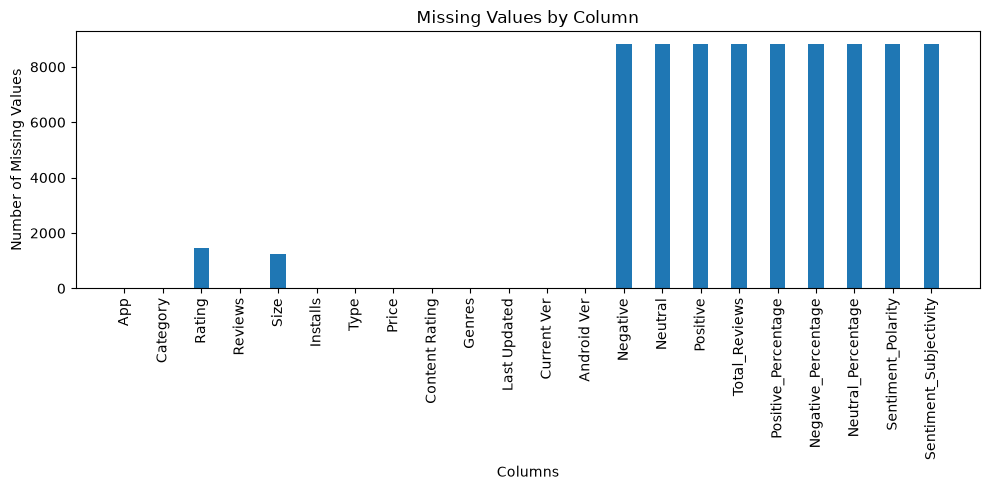

In [38]:
# Visualizing the missing values
missing_values = combined_data.isnull().sum()

plt.figure(figsize=(10, 5))
plt.bar(missing_values.index, missing_values.values, width=0.4)
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values by Column')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Missing Values — Observation

- The missing values in `Rating`, `Size`, `Current Ver`, and `Android Ver` were already investigated during the individual App dataset analysis and were retained where no reliable imputation was possible.
- The aggregated review columns contain **8,842 missing values each**. These missing values are a result of the left merge because only **816 of the 9,658 apps** had matching review information in the User Review dataset.
- Therefore, these values do not represent data-quality issues in the combined dataset; they indicate that **review-level information was unavailable for those applications**.
- The missing review metrics will be retained as `NaN` rather than imputed, since assigning sentiment values to apps without review data could introduce misleading information.

In [39]:
# check the apps that do not exists in app_data but exists in review_summary
missing_apps = review_summary[~review_summary['App'].isin(app_data['App'])]

In [ ]:
# show those apps which do not exists in app_data but exists in review_summary
missing_apps[['App']].head(50)

,App
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室
16,591房屋交易-租屋、中古屋、新建案、實價登錄、別墅透天、公寓套房、捷運、買房賣房行情、房價...
17,591房屋交易-香港
39,ANA
73,AirBrush: Easy Photo Editor
133,Apple Daily 蘋果動新聞
134,Aprender inglés con Wlingua
167,BaBe - Baca Berita
168,BaBe Lite - Baca Berita Hemat Kuota
169,BaBe+ - Berita Indonesia


In [ ]:
# total no of missing apps that do not exists in app_data but exists in review_summary
missing_apps.shape[0]

49

In [44]:
missing_apps['App'].to_list()

['104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室',
 '591房屋交易-租屋、中古屋、新建案、實價登錄、別墅透天、公寓套房、捷運、買房賣房行情、房價房貸查詢',
 '591房屋交易-香港',
 'ANA',
 'AirBrush: Easy Photo Editor',
 'Apple Daily 蘋果動新聞',
 'Aprender inglés con Wlingua',
 'BaBe - Baca Berita',
 'BaBe Lite - Baca Berita Hemat Kuota',
 'BaBe+ - Berita Indonesia',
 'Baca- Berita Terbaru, Informasi, Gosip dan Politik',
 'Bagan - Myanmar Keyboard',
 'Banco Itaú',
 'Banco do Brasil',
 'Bancomer móvil',
 'Bangla Newspaper – Prothom Alo',
 'Banque Populaire',
 'Birdays – Birthday reminder',
 'Brasileirão Pro 2018 - Série A e B',
 'Buienradar - weer',
 'Bukalapak - Jual Beli Online',
 'BukuBayi - Perkembangan Bayi',
 'Buscapé - Ofertas e descontos',
 'BÁO MỚI - Đọc Báo, Tin Tức 24h',
 'CAIXA',
 'Caf - Mon Compte',
 'Claro',
 'ColorFil - Adult Coloring Book',
 'Curso de Ingles Gratis',
 'Cut the Rope 2',
 'DELISH KITCHEN - 無料レシピ動画で料理を楽しく・簡単に！',
 'Daum Mail - 다음 메일',
 'Delivery Club–Доставка еды:пицца,суши,бургер,салат',
 'Despegar.com Hoteles y Vuelos',
 'Detector 

### Merge Validation — Observation

- The review summary contained 865 unique apps, of which 816 were successfully matched with the App dataset.
- The remaining 49 apps were not found in the App dataset.
- Inspection of the unmatched app names suggests that they are genuine application records rather than duplicate or obvious formatting errors.
- Since there is no reliable basis for manually matching these applications to records in the App dataset, they were left unmatched rather than artificially modifying the app names.
- The combined dataset therefore retains all 9,658 apps from the App dataset, with review metrics available only for apps having a valid match.

## Data Visualization

In [ ]:
# Category vs Sentiment

# Get top 10 categories based on total reviews for each category
top_categories = (
    combined_data.groupby('Category')['Total_Reviews']
    .sum()
    .nlargest(10)
    .index
)

# calculate the total number of positive, neutral, and negative reviews for each category
category_sentiment = (
    combined_data[combined_data['Category'].isin(top_categories)]
    .groupby('Category')[[
        'Positive',
        'Neutral',
        'Negative'
    ]]
    .sum()
)

# Convert counts into percentages
category_sentiment_percentage = (
    category_sentiment.div(
        category_sentiment.sum(axis=1),
        axis=0
    ) * 100
).round(2)

category_sentiment_percentage

,Positive,Neutral,Negative
Category,,,
DATING,61.55,17.48,20.98
FAMILY,62.62,10.58,26.80
FINANCE,62.95,14.60,22.46
GAME,58.56,5.02,36.42
HEALTH_AND_FITNESS,77.81,11.22,10.97
MEDICAL,68.34,16.18,15.48
PRODUCTIVITY,66.78,14.89,18.33
SPORTS,63.32,13.32,23.36
TOOLS,60.23,22.68,17.10


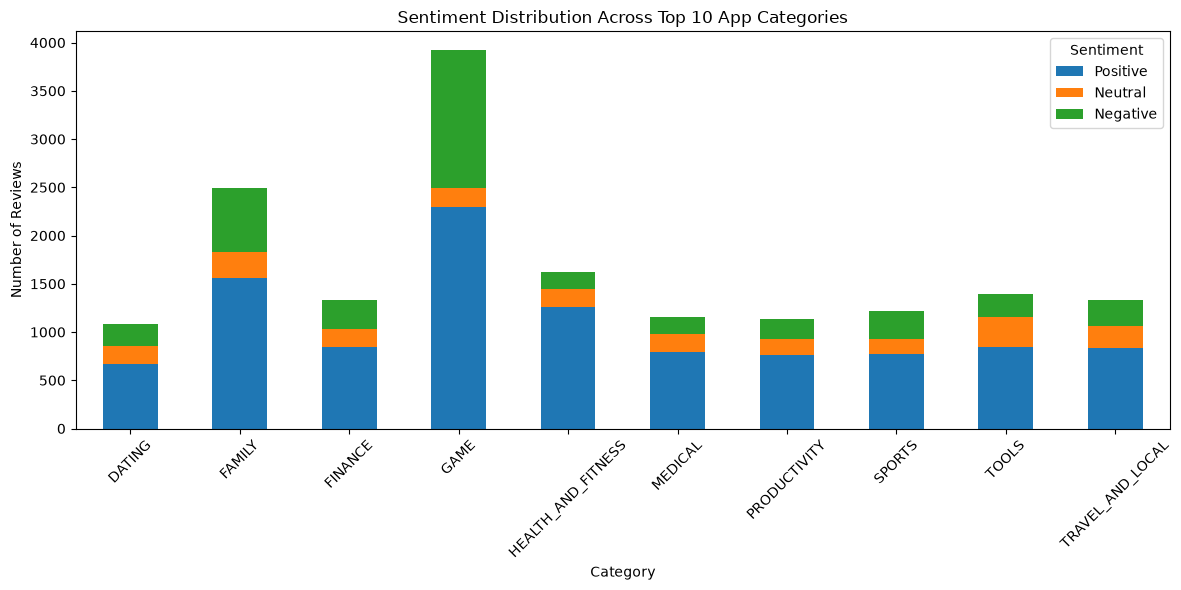

In [48]:
# plotting the chart (top 10 categories vs sentiment percentage)
category_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Sentiment Distribution Across Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### Observation - Key Insights

- Positive reviews have the highest representation across most of the top 10 app categories.
- The **Game** category is an exception, where negative reviews represent the largest share of reviews.
- Neutral reviews generally have the smallest representation across the categories.
- Overall, the distribution indicates that users' feedback is more frequently **positive or negative rather than neutral**, suggesting that users tend to express a clearer opinion when reviewing apps.

In [ ]:
# Type Vs Sentiment

# get the unique types of apps in the dataset and their total reviwes for each types
types = (
    combined_data.groupby('Type')['Total_Reviews']
    .sum()
    .index
)

# calculate the total number of positive, neutral, and negative reviews for each type
type_sentiment = (
    combined_data[combined_data['Type'].isin(types)]
    .groupby('Type')[[
        'Positive',
        'Neutral',
        'Negative'
    ]]
    .sum()
)

# Convert counts into percentages
type_sentiment_percentage = (
    type_sentiment.div(
        type_sentiment.sum(axis=1),
        axis=0
    ) * 100
).round(2)

type_sentiment_percentage

,Positive,Neutral,Negative
Type,,,
Free,64.08,14.43,21.49
Paid,75.58,7.92,16.50


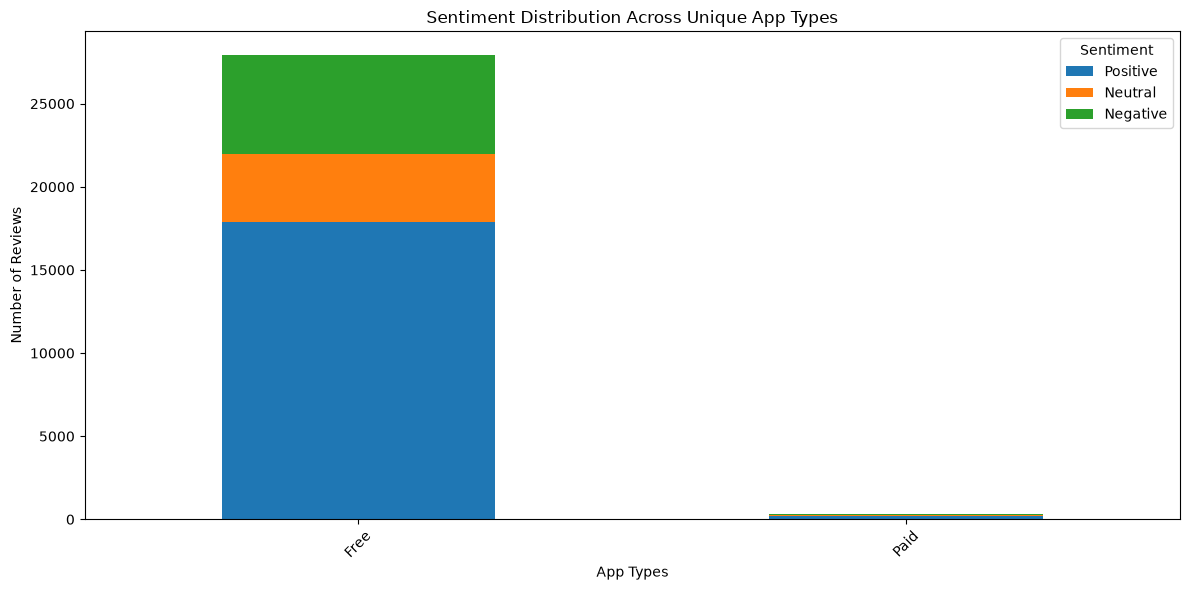

In [50]:
# plotting the chart (Unique Type Vs Sentiment)
type_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Sentiment Distribution Across Unique App Types')
plt.xlabel('App Types')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### Observation

- Free apps have a substantially larger volume of reviews compared with paid apps.
- For Free apps, positive reviews represent the largest share, followed by negative reviews, while neutral reviews have the smallest share.
- Paid apps have a much smaller number of reviews across all three sentiment categories.
- Overall, the review distribution suggests that users are more likely to express clearly positive or negative opinions rather than neutral opinions across both app types.
- The difference in review volume between Free and Paid apps is substantial, indicating much higher user-review activity for Free apps.

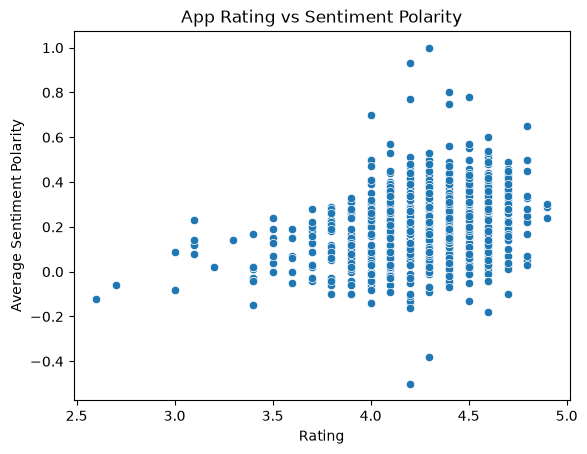

In [53]:
# Rating Vs Sentiment Polarity
sns.scatterplot(
    data=combined_data,
    x='Rating',
    y='Sentiment_Polarity'
)

plt.title('App Rating vs Sentiment Polarity')
plt.xlabel('Rating')
plt.ylabel('Average Sentiment Polarity')
plt.show()

### Observation

- Higher-rated apps generally show **neutral to positive average sentiment polarity**, with most observations concentrated above 0.
- Lower-rated apps tend to have **neutral to negative average sentiment polarity**, with more observations appearing around or below 0.
- Overall, the plot suggests a **positive relationship between app rating and average sentiment polarity**: apps with higher ratings tend to receive more positive reviews, while lower-rated apps tend to have more neutral or negative sentiment.
- However, the considerable spread of points indicates that the relationship is **not perfectly consistent** across all apps.

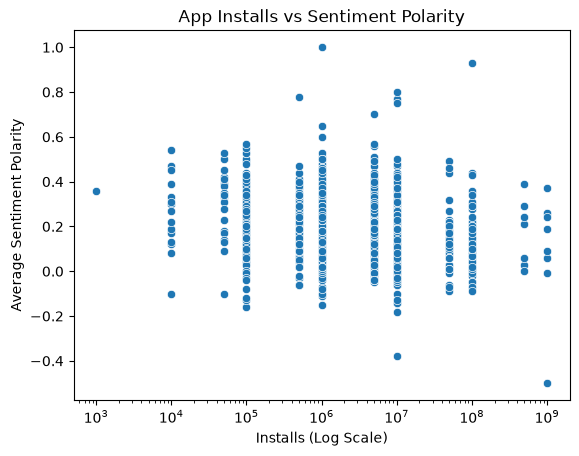

In [54]:
# Installs Vs Sentiment Polarity
sns.scatterplot(
    data=combined_data,
    x='Installs',
    y='Sentiment_Polarity'
)

plt.xscale('log')

plt.title('App Installs vs Sentiment Polarity')
plt.xlabel('Installs (Log Scale)')
plt.ylabel('Average Sentiment Polarity')
plt.show()

### Observation

- Apps with **higher install counts** generally show **neutral to positive average sentiment polarity**.
- Apps with **lower install counts** show a wider spread, with more observations around **neutral to negative polarity**.
- Overall, the plot suggests that more-installed apps tend to have relatively more positive average sentiment, while lower-installed apps are more likely to have neutral or negative sentiment.
- However, there is considerable variation at each install level, so the relationship is **not perfectly consistent**.

## Business Recommendations

Based on the analysis of app characteristics, popularity, ratings, and user sentiment, the following recommendations can be made:

1. **Prioritize user experience and app quality**
   - Positive reviews and higher sentiment polarity are generally associated with higher app ratings.
   - Developers should focus on improving features, usability, performance, and overall user experience to encourage positive feedback.

2. **Monitor negative user feedback**
   - Negative reviews provide valuable information about user dissatisfaction.
   - Developers should regularly analyze negative feedback to identify recurring issues and prioritize improvements.

3. **Focus on highly installed apps**
   - Highly installed apps generate substantially more user engagement and reviews.
   - Popular apps should continuously monitor user sentiment because issues affecting these apps can impact a large user base.

4. **Maintain competitive pricing strategies**
   - The Play Store is dominated by free apps, while paid apps represent a much smaller portion of the dataset.
   - Developers considering paid models should carefully evaluate pricing and clearly communicate the value provided by the app.

5. **Use category-specific sentiment insights**
   - Sentiment differs across app categories, with the Game category showing a relatively higher representation of negative reviews compared with other major categories.
   - Developers should consider category-specific user expectations when prioritizing product improvements.

6. **Use reviews as a continuous feedback source**
   - User reviews can provide actionable insights beyond numerical ratings.
   - Combining review sentiment with ratings and install levels can help businesses identify areas requiring attention and understand user perception more effectively.

## Final Conclusion

This project analyzed Google Play Store applications and user reviews to understand app characteristics, popularity, ratings, and user sentiment.

The analysis showed that the Play Store is heavily dominated by free applications, with categories such as Family and Game having a strong presence. App ratings were generally concentrated toward the higher end, while reviews and installs showed highly right-skewed distributions, indicating that a relatively small number of apps receive a very large amount of user engagement.

The user review analysis showed that positive sentiment was the most common, while neutral sentiment represented a smaller share of reviews. Sentiment polarity was generally concentrated around neutral to positive values, and sentiment polarity and subjectivity showed only a weak relationship.

The combined analysis provided further insights. Higher-rated apps generally tended to have more positive average sentiment polarity, while lower-rated apps showed more neutral-to-negative sentiment. Similarly, highly installed apps generally showed neutral-to-positive average sentiment, although considerable variation existed across individual apps. Free apps also generated substantially more reviews than paid apps.

Overall, the analysis demonstrates that **app popularity, ratings, and user sentiment are useful complementary measures for understanding app performance and user perception**. Combining app-level information with review-level sentiment provides a more comprehensive view than analyzing either dataset independently.